In [42]:
# data processing
import pandas as pd
import numpy as np
from collections import Counter
import imblearn
from pylab import *
%matplotlib inline
import rasterio
from classification_aux import inpsectiontocsv
import os
import multiprocessing as mp
import rasterio as rio

# modelling
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [43]:
data_dir = '/network/scratch/m/matthew.fortier/lichen'
runname = ""
test_sites = ['CG1-8B', 'F3-20B', 'CS-103A', 'ZF20-11A']
chicken_columns = [f'chicken_{i}' for i in range(1024)]
non_predictive_columns = ['x_pos', 'y_pos', 'site'] # These are removed before training

In [3]:
runpath = os.path.join('runs', runname)
if not os.path.exists(runpath):
    os.mkdir(runpath)

In [28]:
def split_by_sites(df, sites, remove_site=False):
    site_indices = df['site'].isin(sites)

    selection = list(df.columns)
    '''
    if remove_site:
        selection.remove('site')
    '''
    selection.remove('veg_class')

    X = df[selection]
    y = df['veg_class']
    X_train = X[~site_indices].reset_index(drop=True)
    X_test = X[site_indices].reset_index(drop=True)
    y_train = y[~site_indices].reset_index(drop=True)
    y_test = y[site_indices].reset_index(drop=True)

    return X_train, X_test, y_train, y_test

In [5]:
def split_by_columns(df, columns):
    df2 = df[columns]
    df1 = df.drop(columns, axis=1)
    return df1, df2

In [20]:
def run_experiment(X_train, X_test, y_train, y_test, extra_metrics=False):
    # remove irrelevant columns
    X_train = X_train.drop(columns=non_predictive_columns)
    X_test = X_test.drop(columns=non_predictive_columns)

    # -------------------------------
    # oversample w synthetic minority oversampling to balance classes
    under = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = under.fit_resample(X_train, y_train)

    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    clf=RandomForestClassifier(n_estimators=500, max_depth=10, n_jobs=12)
    clf.fit(X_res, y_res)

    # -----------------------------------------------------------------------------------------------------------
    # Prediction
    preds = clf.predict(X_test)

    print(f'  Train accuracy: {clf.score(X_res, y_res)}')
    print(f'  Test accuracy: {clf.score(X_test, y_test)}')

    if extra_metrics:
        # -----------------------------------------------------------------------------------------------------------
        # Inspect performance parameters: training and testing scores, confusion matrix, and feature importanceax1 = plt.figure(figsize=(5,5)).add_subplot(111)

        cf_matrix = confusion_matrix(y_test, preds,  labels = clf.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=clf.classes_)
        disp.plot()
        plt.title('Confusion Matrix')

        feature_importance = pd.DataFrame(clf.feature_importances_, index=X_res.columns).sort_values(by=0, ascending=False)
        print(feature_importance)

    return preds

In [ ]:
def export_tif(X_test, y_pred, y_test, site):
    df = X_test[['site', 'y_pos', 'x_pos']]
    
    df['veg_class'] = y_test
    df['predicted'] = y_pred
    
    
    df = df[df['site'] == site]
    
    rgb_file = os.path.join(data_dir, site, f'{site}_hp_transparent_mosaic_group1.tif')
    op_file = os.path.join(f'{site}_predictions.tif')
    
    with rio.open(rgb_file, 'r') as rgb:
        op_array = np.zeros((3, rgb.height, rgb.width), dtype=uint8)
        for _, row in df.iterrows():
            op_array[0,row['y_pos'],row['x_pos']] = 2 if row['veg_class'] == row['predicted'] else 1 
            op_array[1,row['y_pos'],row['x_pos']] = row['veg_class']
            op_array[2,row['y_pos'],row['x_pos']] = row['predicted']
            
        meta = rgb.meta
        meta['count'] = 3
        with rio.open(op_file, 'w', **meta) as f:
            f.set_band_description(1, 'Error')
            f.set_band_description(2, 'Ground Truth')
            f.set_band_description(3, 'Predicted')
            f.write(op_array[0], 1)
            f.write(op_array[1], 2)
            f.write(op_array[2], 3)

In [7]:

df = pd.read_csv("dataset_large_vit_transformed.csv")


In [8]:
dfn, _ = split_by_columns(df, chicken_columns)

In [15]:
# Random forest without texture data
X_train, X_test, y_train, y_test = split_by_sites(dfn, test_sites)
run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 0.7204210177357865
  Test accuracy: 0.6827462418667265


In [31]:
# Random forest with *all* texture data (1024 features for large dino)
X_train, X_test, y_train, y_test = split_by_sites(df, test_sites)
y_pred = run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 0.9462671743088893
  Test accuracy: 0.6404671008309005


In [16]:
# Random forest with 16 texture features
num_features = 16
df_base, df_chicken = split_by_columns(df, chicken_columns)
df_chicken = df_chicken.iloc[:, :num_features]
df_16 = pd.concat([df_base, df_chicken], axis=1)

X_train, X_test, y_train, y_test = split_by_sites(df_16, test_sites)
run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 0.7798276147853472
  Test accuracy: 0.6946376486425847


In [17]:
# Random forest with 32 texture features
num_features = 32
df_base, df_chicken = split_by_columns(df, chicken_columns)
df_chicken = df_chicken.iloc[:, :num_features]
df_32 = pd.concat([df_base, df_chicken], axis=1)

X_train, X_test, y_train, y_test = split_by_sites(df_32, test_sites)
run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 0.7997845184816841
  Test accuracy: 0.6894772268341934


In [19]:
# New dataset with embedding of texture features
num_features = 32

# We're going to split the train data into train/val, so we can train an encoder on texture features
X_train, X_test, y_train, y_test = split_by_sites(df, test_sites)

# Peel off the texture features in the train set so we can train an encoder
df_main_tr, df_chicken_tr = split_by_columns(X_train, chicken_columns)
df_main_te, df_chicken_te = split_by_columns(X_test, chicken_columns)

softmax_to_class = {1:0, 4:1, 5:2, 6:3, 7:4, 8:5, 9:6, 10:7, 12:8, 13:9}

X_train_chicken = torch.tensor(df_chicken_tr.values, dtype=torch.float)
X_test_chicken  = torch.tensor(df_chicken_te.values, dtype=torch.float)
y_train_chicken = torch.tensor([softmax_to_class[y] for y in y_train.values])
y_test_chicken  = torch.tensor([softmax_to_class[y] for y in y_test.values])

In [83]:
class FFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.5):
        super(FFNN, self).__init__()
        self.dropout = nn.Dropout(p=dropout_prob)
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.constant_(self.fc2.bias, 0)

    def forward(self, x):
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def encode(self, x):
        return self.fc1(x)

In [87]:
# NN training for dino feature downprojection
num_epochs = 2001

network = FFNN(len(chicken_columns), num_features, 10)
loss_fn = nn.CrossEntropyLoss()
opt = optim.AdamW(network.parameters(), lr=0.000001, betas=(0.9, 0.999))

train_dataset = TensorDataset(X_train_chicken, y_train_chicken)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataset = TensorDataset(X_test_chicken, y_test_chicken)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True)

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

# Iterate over the dataloader for multiple epochs
for epoch in range(num_epochs):
    train_loss = train_correct = train_total = 0
    test_loss  = test_correct  = test_total  = 0
    
    network.train()
    for inputs, targets in train_dataloader:
        y_pred = network(inputs) 
        loss = loss_fn(y_pred, targets)
        train_loss += loss.detach().numpy()
        
        _, predicted = torch.max(y_pred.data, 1)
        train_total += targets.size(0)
        train_correct += (predicted == targets).sum().item()

        opt.zero_grad()
        loss.backward()
        opt.step()
    train_losses.append(train_loss / len(train_dataloader))
    train_accuracies.append(100 * train_correct / train_total)
    

    network.eval()
    with torch.no_grad():
        for inputs, targets in test_dataloader:
            y_pred = network(inputs)
            loss = loss_fn(y_pred, targets).item()
            test_loss += loss

            _, predicted = torch.max(y_pred.data, 1)
            test_total += targets.size(0)
            test_correct += (predicted == targets).sum().item()

    test_losses.append(test_loss / len(test_dataloader))
    test_accuracies.append(100 * test_correct / test_total)
    
    if epoch % 200== 0:
        print(f'Finished epoch {epoch}')
        print(f'    Training loss: {train_losses[-1]:.4f}')
        print(f'    Training accuracy: {train_accuracies[-1]:.2f}%')
        print(f'    Test loss: {test_losses[-1]:.4f}')
        print(f'    Test accuracy: {test_accuracies[-1]:.2f}%')


Finished epoch 0
    Training loss: 3.8338
    Training accuracy: 8.58%
    Test loss: 3.8200
    Test accuracy: 7.29%
Finished epoch 200
    Training loss: 1.9631
    Training accuracy: 29.51%
    Test loss: 1.8246
    Test accuracy: 37.24%
Finished epoch 400
    Training loss: 1.7395
    Training accuracy: 36.50%
    Test loss: 1.6245
    Test accuracy: 42.11%
Finished epoch 600
    Training loss: 1.6308
    Training accuracy: 40.91%
    Test loss: 1.5448
    Test accuracy: 43.57%
Finished epoch 800
    Training loss: 1.5659
    Training accuracy: 43.07%
    Test loss: 1.5061
    Test accuracy: 44.38%
Finished epoch 1000
    Training loss: 1.5102
    Training accuracy: 45.54%
    Test loss: 1.4819
    Test accuracy: 45.14%
Finished epoch 1200
    Training loss: 1.4706
    Training accuracy: 46.95%
    Test loss: 1.4693
    Test accuracy: 45.34%
Finished epoch 1400
    Training loss: 1.4398
    Training accuracy: 48.27%
    Test loss: 1.4630
    Test accuracy: 45.30%
Finished epoch 16

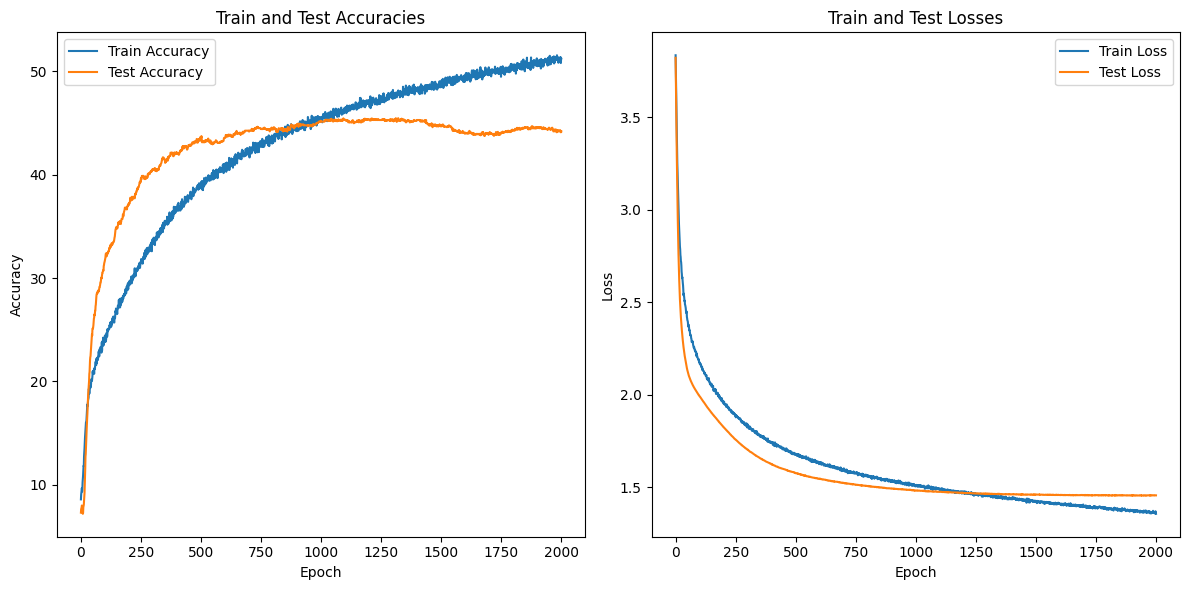

In [88]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot train and test accuracies
axs[0].plot(range(num_epochs), train_accuracies, label='Train Accuracy')
axs[0].plot(range(num_epochs), test_accuracies, label='Test Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Train and Test Accuracies')
axs[0].legend()

# Plot train and test losses
axs[1].plot(range(num_epochs), train_losses, label='Train Loss')
axs[1].plot(range(num_epochs), test_losses, label='Test Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Train and Test Losses')
axs[1].legend()

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


In [89]:
y_pred = network(X_test_chicken)
y_pred = torch.max(y_pred.data, 1)[1].detach().numpy()
y_targ = y_test_chicken.detach().numpy()

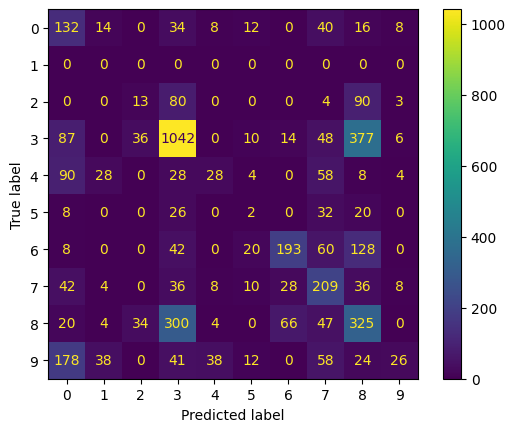

In [90]:
conf_matrix = confusion_matrix(y_targ, y_pred)
ConfusionMatrixDisplay(conf_matrix).plot()

0.3634731882432129

In [65]:
pd.DataFrame(y_pred).value_counts()

3    1394
8     987
0     476
7     356
6     340
5     287
9     214
2     164
4     156
1      83
Name: count, dtype: int64

In [27]:
df_chicken_tr_reduced = pd.DataFrame(network.encode(torch.tensor(df_chicken_tr.values, dtype=torch.float)).detach().numpy(), columns=[f'chicken_{i}' for i in range(num_features)])
df_chicken_te_reduced = pd.DataFrame(network.encode(torch.tensor(df_chicken_te.values, dtype=torch.float)).detach().numpy(), columns=[f'chicken_{i}' for i in range(num_features)])

# Concat the reduced texture features back onto the rgb features
X_train = pd.concat([df_main_tr, df_chicken_tr_reduced], axis=1)
X_test = pd.concat([df_main_te, df_chicken_te_reduced], axis=1)

run_experiment(X_train, X_test, y_train, y_test)

  Train accuracy: 0.8811370793966518
  Test accuracy: 0.699798070450976


In [29]:
len(y_train)

23565

[  0 275 274 273 272 271 270 269 268 267 266 265 264 263 262 261 260 259
 258 257 256 255 276 254 277 279 300 299 298 297 296 295 294 293 292 291
 290 289 288 287 286 285 284 283 282 281 280 278 253 252 251 224 223 222
 221 220 219 218 217 216 215 214 213 212 211 210 209 208 207 206 205 204
 225 226 227 228 250 249 248 247 246 245 244 243 242 241 301 240 238 237
 236 235 234 233 232 231 230 229 239 203 302 304 376 375 374 373 372 371
 370 369 368 367 366 365 364 363 362 361 360 359 358 357 356 377 355 378
 380 401 400 399 398 397 396 395 394 393 392 391 390 389 388 387 386 385
 384 383 382 381 379 354 353 352 325 324 323 322 321 320 319 318 317 316
 315 314 313 312 311 310 309 308 307 306 305 326 327 328 329 351 350 349
 348 347 346 345 344 343 342 303 341 339 338 337 336 335 334 333 332 331
 330 340 202 201 200  72  71  70  69  68  67  66  65  64  63  62  61  60
  59  58  57  56  55  54  53  52  73  51  74  76  97  96  95  94  93  92
  91  90  89  88  87  86  85  84  83  82  81  80  7

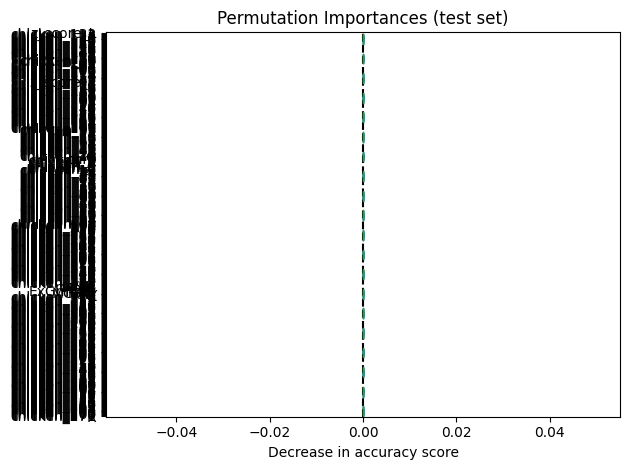

In [21]:
# ==========================================================================================
# Calculate permutation matrix and save figure
# ==========================================================================================
perm_importance = permutation_importance(clf, X_test, y_test)
sorted_idx = perm_importance.importances_mean.argsort()
print(sorted_idx)
importances = pd.DataFrame(
    perm_importance.importances[sorted_idx].T,
    columns=X.columns[sorted_idx],
)

ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
figname = f'perm_{runname}.png'
savefig(savepath+figname, dpi=150, bbox_inches='tight')

In [6]:
# ==========================================================================================
# save classifier in object 
# ==========================================================================================

# Add columns attribute to classifier. 
# This is important information as .tifs that should be classified need to have the same features and in the same order
clf.col_names=X.columns

# -----------------------------------------------------------------------------------------------------------
# !! careful this can make objects of several GB size
outpath = 'data/clfs/'
outfile = 'clf_%s_TEST.pkl' % run
joblib.dump(clf, outpath+outfile) 

['data/clfs/clf_run6_orthotest_500-15_TEST.pkl']

In [ ]:
'''
dfo = pd.read_csv("prior_dataset_transformed.csv") # Maria's original dataset



# Correct wrong chm values in new dataset, using old dataset as a reference.
# This is a temporary measure while I figure out a more efficient way to get accurate chm values
# from the low resolution raster
df_reduced = df[df['site'].isin(dfo['site'].unique())]
dfm = pd.concat([dfo,df_reduced]).drop_duplicates(keep=False, subset=['R', 'G', 'B', 'chm', 'site']).sort_values(['site', 'R', 'G', 'B'])[['site', 'veg_class', 'R', 'G', 'B', 'chm']]
print(dfm)
print('cleaning chm values')
#dfm.to_csv('test1.csv')
for i, (index, cur_row) in enumerate(dfm.iterrows()):
    if i == 0:
        continue
    prv_row = dfm.iloc[i-1]
    if prev_row['site'] == curr_row['site'] and \
       prev_row['R'] == curr_row['R'] and \
       prev_row['G'] == curr_row['G'] and \
       prev_row['B'] == curr_row['B'] and \
       type(prev_row['veg_class']) == str: # this ensures we're copying from Maria's data to ours
        df.loc[index, 'chm'] = prv_row['chm']

df_reduced = df[df['site'].isin(dfo['site'].unique())]
dfm = pd.concat([dfo,df_reduced]).drop_duplicates(keep=False, subset=['R', 'G', 'B', 'chm', 'site']).sort_values(['site', 'R', 'G', 'B'])[['site', 'veg_class', 'R', 'G', 'B', 'chm']]

#dfm.to_csv('test2.csv')
print(dfm)
'''